In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

from importlib import reload
import numpy as np

In [6]:
from pathlib import Path

SAVE_FIG_PATH = Path("../results/figures/")

In [4]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       135          Method:                  ML          
No. Groups:             15           Scale:                   259.5240    
Min. group size:        9            Log-Likelihood:          -582.9639   
Max. group size:        9            Converged:               Yes         
Mean group size:        9.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      26.569    6.686  3.974 0.000  13.464 39.675
condition[T.opto]              -3.887    9.788 -0.397 0.691 -23.071 15.297
day_on_maze                     8.667    0.735 11.786 0.000   7.225 10.108
condition[T.opto]:day_on_maz

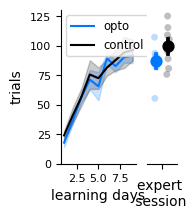

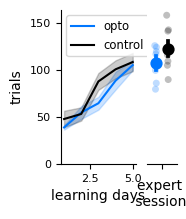

In [ ]:
reload(bl)
for maze_order in [1, 2]:
    fig, axes = plt.subplots(1, 2, figsize=(1.5, 2), width_ratios=[1, 0.4], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=True, axes=axes)
    fig.savefig(SAVE_FIG_PATH / f"opto_trials_maze_{maze_order}.pdf")

In [ ]:
from GridMaze.analysis.behaviour import performance_metrics as pm

In [10]:
performance_df = pm.get_performance_df()

Mixed ANOVA: n_excess_steps
+-------------+----------+-------+-------+----------+----------+-------------+----------+-------+
| Source      |       SS |   DF1 |   DF2 |       MS |        F |       p-unc |      np2 |   eps |
|-------------+----------+-------+-------+----------+----------+-------------+----------+-------|
| condition   | 10.6708  |     1 |    13 | 10.6708  |  6.40357 | 0.0250999   | 0.33002  |   nan |
| stim_trial  |  4.77945 |     1 |    13 |  4.77945 | 35.0844  | 5.04046e-05 | 0.729642 |     1 |
| Interaction |  2.16722 |     1 |    13 |  2.16722 | 15.9088  | 0.00154493  | 0.55031  |   nan |
+-------------+----------+-------+-------+----------+----------+-------------+----------+-------+


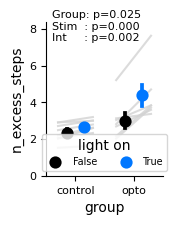

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
pm.plot_random_effects_summary(
    performance_df,
    y="n_excess_steps",
    stim_day_range=(6, np.inf),
    print_stats=True,
    ax=ax,
)
fig.savefig(SAVE_FIG_PATH / "exess_steps.pdf")

In [20]:
from GridMaze.analysis.strategies import get_input_data as gid
from GridMaze.analysis.strategies import comparisons as com

In [21]:
navigation_strategies_df = gid.get_navigation_strategies_df(
    n_history=1,
    verbose=False,
)

[H≠S: habit != structure]: kept 40988/124788 decisions (32.8%)
Mixed ANOVA: prob_correct
+-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |       F |       p-unc |      np2 |   eps |
|-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------|
| condition   | 0.033982  |     1 |    13 | 0.033982  | 10.966  | 0.00562205  | 0.457564 |   nan |
| stim_trial  | 0.0463051 |     1 |    13 | 0.0463051 | 60.5598 | 3.02195e-06 | 0.823273 |     1 |
| Interaction | 0.0142317 |     1 |    13 | 0.0142317 | 18.6128 | 0.000840771 | 0.588775 |   nan |
+-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------+
[V≠S: vector != structure]: kept 25688/124788 decisions (20.6%)
Mixed ANOVA: prob_correct
+-------------+-------------+-------+-------+-------------+-----------+------------+------------+-------+
| Source      |       

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
3-way mixed ANOVA (condition × stim_trial × scenario, lmer, Type III, Satterthwaite df):
+-------------------------------+------------+------------+---------+-----------+-----------+-------------+-------+
|                               |         SS |         MS |   NumDF |   DenomDF |    F-stat |       P-val | Sig   |
|-------------------------------+------------+------------+---------+-----------+-----------+-------------+-------|
| condition                     | 0.0082721  | 0.0082721  |       1 |        13 |   8.44215 | 0.0122767   | *     |
| stim_trial                    | 0.0807695  | 0.0807695  |       1 |        65 |  82.4299  | 3.59536e-13 | ***   |
| scenario                      | 1.52322    | 0.761611   |       2 |        65 | 777.268   | 4.11615e-46 | ***   |
| condition:stim_trial          | 0.013925   | 0.013925

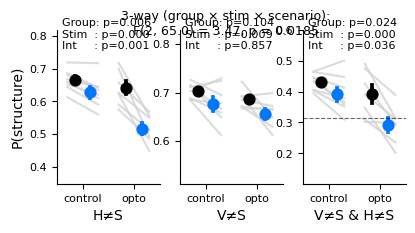

In [22]:
f, axes = plt.subplots(1, 3, figsize=(4.5, 2))
com.plot_prop_across_scenarios(navigation_strategies_df, decision_point_filter="only", axes=axes)
f.savefig(SAVE_FIG_PATH / "group_x_stim_strategy_comparisons.pdf")

In [12]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

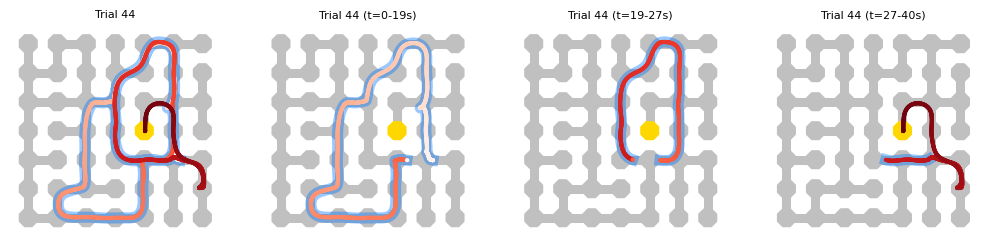

In [13]:
# example session (opto subject)
session = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17], with_data=["navigation_df"])[0]

# example trial
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session, trial=trial, t_range=t_range, ax=ax)
f.savefig(SAVE_FIG_PATH / "opto_trajectory.pdf")

In [14]:
from GridMaze.analysis.errors import errors

In [15]:
error_df = errors.get_error_df()

Mixed ANOVA: repeat_error_rate
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |      p-unc |      np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+------------+----------+-------|
| condition   | 1.43707e-06 |     1 |    13 | 1.43707e-06 |  5.69083 | 0.0329644  | 0.304472 |   nan |
| stim_trial  | 1.75519e-06 |     1 |    13 | 1.75519e-06 | 10.2661  | 0.00691314 | 0.441247 |     1 |
| Interaction | 1.18822e-06 |     1 |    13 | 1.18822e-06 |  6.94987 | 0.0205415  | 0.348367 |   nan |
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+


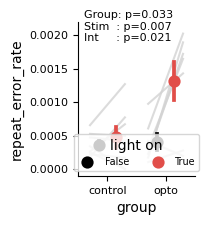

In [16]:
reload(errors)
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
errors.plot_group_by_stim_errors(
    error_df,
    e="repeat_error",
    stim_color="#E14E49",
    stim_day_range=None,
    ax=ax,
    print_stats=True,
    legend=True,
)
ax.set_ylim(-0.0001, 0.0022)
fig.savefig(SAVE_FIG_PATH / "repeat_errors.pdf")

In [17]:
from GridMaze.analysis.errors import correction as corr

In [ ]:
error_cent_df = corr.get_error_centered_df(
    error_df,
    n_jobs=-1,
)

Mixed ANOVA: prob_backtrack
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |      p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+------------+----------+-------|
| condition   | 0.00236122 |     1 |    13 | 0.00236122 | 11.4477  | 0.00489566 | 0.468252 |   nan |
| stim_trial  | 0.00182034 |     1 |    13 | 0.00182034 |  6.93627 | 0.0206425  | 0.347922 |     1 |
| Interaction | 0.00292567 |     1 |    13 | 0.00292567 | 11.1481  | 0.00533365 | 0.461654 |   nan |
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+


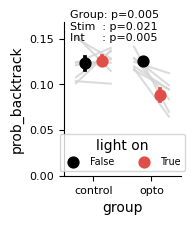

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
corr.plot_group_by_stim_error_backtrack(error_cent_df, stim_color="#E14E49", ax=ax)
fig.savefig(SAVE_FIG_PATH / "summary_error_backtracking.pdf")